# Pre-processing News Data

## Bài toán
Dữ liệu gồm n văn bản phân vào 10 chủ đề khác nhau. Cần biễu diễn mỗi văn bản dưới dạng một vector số thể hiện cho nội dụng của văn bản đó.

## Sử dụng phương pháp mã hóa: TF-IDF
Cho tập gồm $n$ văn bản: $D = \{d_1, d_2, ... d_n\}$. Tập từ điển tương ứng được xây dựng từ $n$ văn bản này có độ dài là $m$
- Xét văn bản $d$ có $|d|$ từ và $t$ là một từ trong $d$. Mã hóa tf-idf của $t$ trong văn bản $d$ được biểu diễn:
\begin{equation}
    \begin{split}
        \text{tf}_{t, d} &= \frac{f_t}{|d|} \\
        \text{idf}_{t, d} &= \log\frac{n}{n_t}, \ \ \ \ n_t = |\{d\in D: t\in d\}| \\
        \text{tf-idf}_{t d} &= \text{tf}_{t, d} \times \text{idf}_{t, d}
    \end{split}
\end{equation}

- Khi đó văn bản $d$ được mã hóa là một vector $m$ chiều. Các từ xuất hiện trong d sẽ được thay bằng giá trị tf-idf tương ứng. Các từ không xuất hiện trong $d$ thì thay là 0

## Chuẩn bị các thư viện cần thiết

In [1]:
# Đã được cài sẵn trong môi trường conda "course"
# !pip install pyvi
print("Thư viện pyvi đã sẵn sàng trong môi trường.")

Thư viện pyvi đã sẵn sàng trong môi trường.


In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_files
from pyvi import ViTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

%matplotlib inline

In [3]:
# Nếu chạy trên Google Colab thì bỏ comment dòng sau:
# from google.colab import drive
# drive.mount("/content/drive")
print("Bỏ qua bước mount drive do đang chạy trực tiếp trên máy cá nhân.")

Bỏ qua bước mount drive do đang chạy trực tiếp trên máy cá nhân.


## Load dữ liệu từ thư mục

Cấu trúc thư mục như sau

- data/news_vnexpress/

    - Kinh tế:
        - bài báo 1.txt
        - bài báo 2.txt
    - Pháp luật
        - bài báo 3.txt
        - bài báo 4.txt

In [4]:
#Có thể chỉnh lại đường dẫn thư mục cho phù hợp
INPUT = 'data/news_vnexpress'
os.makedirs("images",exist_ok=True)  # thư mục lưu các các hình ảnh trong quá trình huấn luyện và đánh gía

In [5]:
# statistics
print('Các nhãn và số văn bản tương ứng trong dữ liệu')
print('----------------------------------------------')
n = 0
for label in os.listdir(INPUT):
    print(f'{label}: {len(os.listdir(os.path.join(INPUT, label)))}')
    n += len(os.listdir(os.path.join(INPUT, label)))

print('-------------------------')
print(f"Tổng số văn bản: {n}")

Các nhãn và số văn bản tương ứng trong dữ liệu
----------------------------------------------
doi-song: 121
du-lich: 55
phap-luat: 60
the-thao: 174
thoi-su: 60
suc-khoe: 163
giai-tri: 202
giao-duc: 106
kinh-doanh: 263
khoa-hoc: 145
-------------------------
Tổng số văn bản: 1349


In [6]:
# load data
data_train = load_files(container_path=INPUT, encoding="utf-8")
print('mapping:')
for i in range(len(data_train.target_names)):
    print(f'{data_train.target_names[i]} - {i}')

print('--------------------------')
print(data_train.filenames[0:1])
# print(data_train.data[0:1])
print(data_train.target[0:1])
print(data_train.data[0:1])

print("\nTổng số  văn bản: {}" .format( len(data_train.filenames)))

mapping:
doi-song - 0
du-lich - 1
giai-tri - 2
giao-duc - 3
khoa-hoc - 4
kinh-doanh - 5
phap-luat - 6
suc-khoe - 7
the-thao - 8
thoi-su - 9
--------------------------
['data/news_vnexpress/kinh-doanh/00212.txt']
[5]
['Đại diện Công ty TNHH Bảo hiểm Nhân thọ Sun Life Việt Nam (Sun Life Việt Nam) chi biết, khi nhận được thông tin ông Tống Văn Đại bị bệnh hiểm nghèo, đơn vị đã cắt cử nhân viên đến thăm hỏi sức khỏe khách hàng.Sun Life Việt Nam cũng tiến hành các thủ tục để chi trả quyền lợi như đã cam kết của hợp đồng bảo hiểm. Với số tiền được chi trả từ quyền lợi bảo hiểm, Sun Life Việt Nam mong muốn ông Đại và người thân có thêm nguồn tài chính để yên tâm điều trị bệnh, bồi dưỡng sức khỏe, mau chóng trở lại với một cuộc sống khỏe mạnh hơn.Tại lễ chi trả quyền lợi bảo hiểm vào 21/2, khách hàng còn được tư vấn, giới thiệu về các giải pháp tài chính bảo hiểm của Sun Life Việt Nam giúp người dùng được bảo vệ tài chính trước rủi ro và mang đến cơ hội gia tăng tài sản. Khách hàng có cơ hội h

## Chuyển dữ liệu dạng text về ma trận (n x m) bằng TF-IDF

* Bạn cần viết đoạn mã tương ứng trong cell bên dưới. Theo các bước được gợi ý

In [ ]:
# load dữ liệu các stopwords
with open("vietnamese-stopwords.txt", "r", encoding="utf-8") as f:
    stopwords = [line.strip().replace(" ", "_") for line in f if line.strip()]

# Chuyển hoá dữ liệu text về dạng vector TF
#     - tách từ tiếng Việt với ViTokenizer
#     - loại bỏ từ dừng
#     - sinh từ điển
text_tokenized = [ViTokenizer.tokenize(text) for text in data_train.data]

module_count_vector = CountVectorizer(stop_words=stopwords)
X_tf = module_count_vector.fit_transform(text_tokenized)

# Hàm thực hiện chuyển đổi dữ liệu text thành dữ liệu số dạng ma trận TF-IDF
tfidf_transformer = TfidfTransformer()
data_preprocessed = tfidf_transformer.fit_transform(X_tf)

X = data_preprocessed 
Y = data_train.target

print(f"\nSố lượng từ trong từ điển: {len(module_count_vector.vocabulary_)}")
print(f"Kích thước dữ liệu sau khi xử lý: {X.shape}")
print(f"Kích thước nhãn tương ứng: {Y.shape}")



Số lượng từ trong từ điển: 24355
Kích thước dữ liệu sau khi xử lý: (1349, 24355)
Kích thước nhãn tương ứng: (1349,)


In [8]:
print(X[100].toarray())
print(Y[100])

[[0. 0. 0. ... 0. 0. 0.]]
7


In [9]:
print(X[100]) #Sau khi xử lí, dữ liệu được lưu dưới dạng ma trận thưa như sau:

  (0, 24348)	0.08205481740668466
  (0, 24213)	0.02997128147822779
  (0, 23257)	0.05219448853211658
  (0, 23147)	0.057792836596678665
  (0, 23145)	0.07929852363051189
  (0, 22750)	0.09545655421054804
  (0, 22712)	0.0544290584484068
  (0, 22584)	0.036591155752790046
  (0, 22572)	0.05219448853211658
  (0, 22157)	0.05219448853211658
  (0, 22101)	0.04282040603266016
  (0, 22095)	0.08770739556073096
  (0, 22046)	0.04576693382014912
  (0, 22003)	0.053249573643325034
  (0, 21717)	0.05219448853211658
  (0, 20959)	0.027521347421153322
  (0, 20921)	0.09001201481690382
  (0, 20192)	0.044298839801194
  (0, 19564)	0.11015070041022024
  (0, 19401)	0.04170658734207381
  (0, 19132)	0.04039138250015442
  (0, 18851)	0.13222138672789793
  (0, 18564)	0.034335525793874826
  (0, 18453)	0.04576693382014912
  (0, 18444)	0.07738964247080442
  :	:
  (0, 6736)	0.06363770280703203
  (0, 6672)	0.036486295668193815
  (0, 5926)	0.059135696683185426
  (0, 5919)	0.0315604100515197
  (0, 5639)	0.1088581168968136
  (0, 5

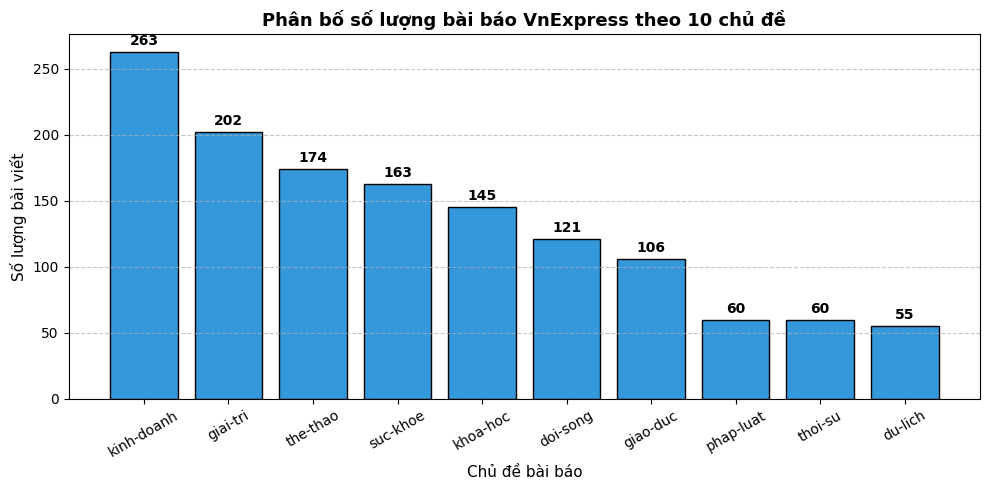

Chủ đề thực tế của bài báo số 100: [suc-khoe]
Top 10 từ khóa có trọng số TF-IDF cao nhất trong bài báo này:
 - Từ khóa: chợ             | Điểm TF-IDF: 0.6648
 - Từ khóa: hàng            | Điểm TF-IDF: 0.3247
 - Từ khóa: ho              | Điểm TF-IDF: 0.2130
 - Từ khóa: quầy            | Điểm TF-IDF: 0.1511
 - Từ khóa: sốt             | Điểm TF-IDF: 0.1381
 - Từ khóa: biểu_hiện       | Điểm TF-IDF: 0.1365
 - Từ khóa: thở             | Điểm TF-IDF: 0.1322
 - Từ khóa: khẩu_trang      | Điểm TF-IDF: 0.1257
 - Từ khóa: buôn_bán        | Điểm TF-IDF: 0.1183
 - Từ khóa: truy            | Điểm TF-IDF: 0.1102


In [ ]:
# 1. Trực quan hóa số lượng bài báo theo 10 chủ đề
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

label_counts = {label: len(os.listdir(os.path.join(INPUT, label))) for label in os.listdir(INPUT) if os.path.isdir(os.path.join(INPUT, label))}
df_labels = pd.Series(label_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(df_labels.index, df_labels.values, color='#3498db', edgecolor='black')
plt.title('Phân bố số lượng bài báo VnExpress theo 10 chủ đề', fontsize=13, fontweight='bold')
plt.xlabel('Chủ đề bài báo', fontsize=11)
plt.ylabel('Số lượng bài viết', fontsize=11)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3, f'{yval}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Giải mã ý nghĩa của vector X[100]: Trích xuất Top 10 từ khóa đặc trưng nhất của bài báo số 100
feature_names = np.array(module_count_vector.get_feature_names_out())
row_100 = X[100].toarray().flatten()
top_indices = row_100.argsort()[-10:][::-1]

print(f'Chủ đề thực tế của bài báo số 100: [{data_train.target_names[data_train.target[100]]}]')
print('Top 10 từ khóa có trọng số TF-IDF cao nhất trong bài báo này:')
for idx in top_indices:
    if row_100[idx] > 0:
        print(f' - Từ khóa: {feature_names[idx]:<15} | Điểm TF-IDF: {row_100[idx]:.4f}')
